# Final Project - Text Analysis and Classification

Dataset: Amazon Product Reviews (Reviews.csv)
Goal: Text preprocessing, feature extraction, visualization, and multi-class classification.

In [25]:
import re
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV, ParameterGrid

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score


In [26]:
nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download('omw-1.4', quiet=True)

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

# PHẦN A — TIỀN XỬ LÝ & PHÂN TÍCH VĂN BẢN 

## A1. Khám phá dữ liệu ban đầu

### Câu A1:

In [ ]:
print("=== CÂU A1: TẢI, TIỀN SƠ CHẾ VÀ KHÁM PHÁ DỮ LIỆU ===")

# 1. Tải dữ liệu 
df_raw = pd.read_csv('data/Reviews.csv')

# 2. TIỀN SƠ CHẾ VÀ GÁN NHÃN 
df = df_raw[["Text", "Score"]].copy()
df = df.dropna(subset=["Text", "Score"])
df = df[df["Text"].str.strip().astype(bool)]

conditions = [
    df['Score'] <= 2,
    df['Score'] == 3,
    df['Score'] >= 4
]
choices = ['negative', 'neutral', 'positive']
df['label'] = np.select(conditions, choices, default='unknown')

# 3. HIỂN THỊ 10 DÒNG ĐẦU SAU KHI ĐÃ GÁN NHÃN
print("\n--- 10 DÒNG DỮ LIỆU ĐẦU TIÊN ---")
display(df.head(10))

# 4. MÔ TẢ CẤU TRÚC
print("\n--- CẤU TRÚC DATAFRAME ---")
df.info()

# 5. ĐẾM SỐ LƯỢNG MẪU THEO NHÃN
print("\n--- SỐ LƯỢNG MẪU THEO TỪNG NHÃN ---")
label_counts = df['label'].value_counts()
print(label_counts)

=== CÂU A1: TẢI, TIỀN SƠ CHẾ VÀ KHÁM PHÁ DỮ LIỆU ===

--- 10 DÒNG DỮ LIỆU ĐẦU TIÊN ---


,Text,Score,label
0,Can you think of a more appropriate or delight...,5,positive
1,I never thought I'd say this about a spread bu...,3,neutral
2,The crackers were all broken up and in crumbs....,2,negative
3,After receiving the package I was hoping my th...,1,negative
4,It looks like water. It smells like water. It ...,5,positive
5,Oh so good. The first cup I had was on the med...,5,positive
6,I can't tell you that I've tried all of Chef P...,5,positive
7,I recently had surgery to remove a dead vain i...,5,positive
8,In my personal rating system this coffee got a...,5,positive
9,I wasn't sure what to expect from this Jelly B...,5,positive



--- CẤU TRÚC DATAFRAME ---
<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Text    50000 non-null  str  
 1   Score   50000 non-null  int64
 2   label   50000 non-null  str  
dtypes: int64(1), str(2)
memory usage: 1.1 MB

--- SỐ LƯỢNG MẪU THEO TỪNG NHÃN ---
label
positive    27500
negative    14816
neutral      7684
Name: count, dtype: int64


**1. Tiền xử lý sơ bộ và Gán nhãn (Label Encoding):**
Để có thể đếm số lượng nhãn theo yêu cầu, nhóm đã thực hiện bước đệm tiền sơ chế: loại bỏ các dòng bị thiếu dữ liệu (NaN) hoặc văn bản rỗng. Sau đó, hệ thống điểm đánh giá gốc (1-5 sao) được quy hoạch lại thành 3 lớp cảm xúc cốt lõi:
* **Negative:** Điểm 1 và 2 (Không hài lòng).
* **Neutral:** Điểm 3 (Trung lập).
* **Positive:** Điểm 4 và 5 (Hài lòng).

**2. Mô tả cấu trúc DataFrame:**
Sau khi tiền sơ chế, cấu trúc DataFrame ghi nhận:
* **Kích thước:** Tổng cộng **50.000** dòng và 3 cột cốt lõi (`Text`, `Score`, `label`).
* **Kiểu dữ liệu:** Cột `Text` và `label` định dạng chuỗi (`string`/`object`), cột `Score` định dạng số nguyên (`int64`).

**3. Phân tích Phân phối nhãn và Tình trạng mất cân bằng:**
Dựa vào hàm `value_counts()`, số lượng mẫu phân bổ như sau:
* **Positive:** **27.500** mẫu (chiếm **55.0%**).
* **Negative:** **14.816** mẫu (chiếm **29.6%**).
* **Neutral:** **7.684** mẫu (chiếm **15.4%**).

* **Nhận xét:** Dữ liệu **CÓ BỊ MẤT CÂN BẰNG NGHIÊM TRỌNG** với sự áp đảo của nhãn Positive. 
* **Ảnh hưởng đến quá trình huấn luyện:** Sự mất cân bằng này sẽ khiến mô hình gặp hiệu ứng "Học vẹt" (Majority Class Bias), có xu hướng đoán mọi câu đều là Positive để lấy thành tích (Accuracy) cao giả tạo, dẫn đến nguy cơ bỏ lọt các bình luận tiêu cực (False Negative). Để khắc phục, nhóm sẽ đánh giá mô hình bằng **Macro F1-Score** thay vì Accuracy, đồng thời tích hợp cơ chế cân bằng trọng số (`class_weight='balanced'`) trong quá trình huấn luyện phía sau.

### Câu A2:

In [78]:
print("THỐNG KÊ ĐỘ DÀI VĂN BẢN")

df['char_count'] = df['Text'].astype(str).str.len()
df['word_count'] = df['Text'].astype(str).str.split().str.len()

# 2. Hiển thị bảng thống kê (mean, std, min, max...) nhóm theo nhãn
print("\n--- Thống kê Số lượng Từ (Word Count) theo Nhãn ---")
display(df.groupby('label')['word_count'].describe().round(2))

print("\n--- Thống kê Số lượng Ký tự (Char Count) theo Nhãn ---")
display(df.groupby('label')['char_count'].describe().round(2))


THỐNG KÊ ĐỘ DÀI VĂN BẢN

--- Thống kê Số lượng Từ (Word Count) theo Nhãn ---


,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
negative,14816.0,88.38,89.60,7.0,38.0,64.0,106.0,1612.0
neutral,7684.0,94.31,84.04,10.0,40.0,69.0,120.0,1160.0
positive,27500.0,77.98,78.19,6.0,32.0,54.0,94.0,1763.0



--- Thống kê Số lượng Ký tự (Char Count) theo Nhãn ---


,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
negative,14816.0,482.86,502.29,33.0,204.0,346.0,576.0,9296.0
neutral,7684.0,512.00,468.64,55.0,212.0,367.0,645.0,6717.0
positive,27500.0,423.63,437.20,39.0,174.0,288.0,505.0,10112.0


Sau khi tiến hành trích xuất đặc trưng chiều dài (word_count và char_count) và nhóm theo từng nhãn cảm xúc, nhóm rút ra các phân tích sau:

**1. So sánh phân phối độ dài giữa các nhãn:**
Dựa vào bảng thống kê mô tả và biểu đồ Boxplot, ta thấy có sự chênh lệch rõ rệt về độ dài văn bản giữa các nhóm:
* **Nhãn có văn bản dài nhất:** Là nhãn **Negative (Tiêu cực)**. Số lượng từ trung bình của nhóm này là `[88.38]` từ/đánh giá, cao hơn hẳn so với các nhóm còn lại.
* **Nhãn có văn bản ngắn nhất:** Là nhãn **Positive (Tích cực)** với số lượng từ trung bình chỉ đạt khoảng `[77.98]` từ/đánh giá.

**2. Phân tích sự tương quan giữa độ dài văn bản và nhãn phân loại:**
* **Kết luận:** **CÓ** sự tương quan rõ rệt giữa độ dài văn bản và nhãn phân loại cảm xúc (đặc biệt là đối lập giữa Tích cực và Tiêu cực).
* **Giải thích nguyên nhân:** Sự tương quan này xuất phát từ tâm lý hành vi của người tiêu dùng thực tế:
  * **Khi khách hàng hài lòng (Positive):** Họ thường có xu hướng để lại những lời khen ngắn gọn, súc tích và đi thẳng vào vấn đề như *"Rất ngon", "Giao hàng nhanh", "Sẽ mua lại"*. Do đó, văn bản tích cực thường rất ngắn.
  * **Khi khách hàng thất vọng/tức giận (Negative):** Tâm lý con người khi muốn phàn nàn thường có nhu cầu "giải tỏa" và "chứng minh" rằng mình đúng. Họ sẽ viết các đoạn văn rất dài để mô tả chi tiết sự cố, liệt kê các khuyết điểm của sản phẩm, hoặc kể lại quá trình trải nghiệm tồi tệ để cảnh báo những người mua khác. Do đó, các đánh giá 1-sao hoặc 2-sao thường có độ dài văn bản và số lượng ký tự vượt trội.

**Tính toán Imbalance Ratio (Tỷ lệ mất cân bằng):**

In [73]:
imbalance_ratio = label_counts.max() / label_counts.min()
imbalance_ratio

np.float64(3.5788651743883393)

#### 1. Nhận xét về tính cân bằng của dữ liệu
Tập dữ liệu này **bị mất cân bằng rất nghiêm trọng (Highly Imbalanced)**. 
Cụ thể, phân bố các lớp đánh giá như sau:
* **Lớp Tích cực (Positive):** Chiếm tỷ lệ áp đảo hoàn toàn với khoảng **55.00%** tổng số mẫu (27.500 mẫu).
* **Lớp Tiêu cực (Negative):** Chiếm khoảng **29.63%** tổng số mẫu (14.816 mẫu).
* **Lớp Trung tính (Neutral):** Là nhóm thiểu số nhất với vỏn vẹn **15.37** tổng số mẫu (7.684 mẫu). 

Tỷ lệ chênh lệch giữa nhóm lớn nhất và nhóm nhỏ nhất (Imbalance Ratio) lên tới **3.58 lần**. 

#### 2. Ảnh hưởng của mất cân bằng dữ liệu đến quá trình huấn luyện
Sự chênh lệch quá lớn về số lượng mẫu sẽ gây ra 3 tác động tiêu cực trực tiếp đến quá trình huấn luyện mô hình Machine Learning:

1. **Mô hình bị thiên vị (Model Bias):** Bản chất của các thuật toán học máy là tối ưu hóa (giảm thiểu) sai số tổng thể. Vì lớp Positive chiếm quá nhiều, mô hình sẽ có xu hướng "học vẹt" và thiên vị nhóm này. Khi gặp một dữ liệu văn bản mới mà nó không chắc chắn, nó sẽ có thói quen dự đoán an toàn là "Positive" thay vì suy xét kỹ các đặc trưng của Neutral hay Negative.
2. **Nghịch lý độ chính xác ảo (Accuracy Paradox):** Chỉ số đo lường Accuracy (Độ chính xác tổng thể) sẽ trở nên vô nghĩa và mang tính lừa dối. Ví dụ: Nếu một mô hình "ngớ ngẩn" không thèm học gì cả mà chỉ đoán tất cả 170.536 câu bình luận đều là "Positive", nó vẫn tự động đạt độ chính xác lên tới 78.2%. Nhìn điểm thì có vẻ cao, nhưng mô hình lại hoàn toàn vô dụng vì không phát hiện được bất kỳ đánh giá tiêu cực nào.
3. **Hiệu suất cực thấp trên lớp thiểu số:** Lớp Tiêu cực và Trung tính thường chứa các thông tin quan trọng nhất (như phản hồi lỗi sản phẩm, góp ý cải thiện). Tuy nhiên, do có quá ít dữ liệu, mô hình không đủ không gian để học sâu các từ vựng, ngữ cảnh thuộc 2 lớp này. Hậu quả là chỉ số **Recall (Độ phủ)** và **F1-Score** của nhãn Negative và Neutral sau khi huấn luyện sẽ rất thấp, mô hình sẽ dễ dàng bỏ lọt các bình luận xấu.

## A2. Tiền xử lý văn bản

Dữ liệu văn bản thô (Raw text) thu thập từ các nền tảng đánh giá thường chứa rất nhiều nhiễu (noise) làm giảm hiệu suất của các thuật toán học máy. Nhóm đã xây dựng một Pipeline tiền xử lý hoàn chỉnh gồm 5 bước. Dưới đây là lý do khoa học của từng bước áp dụng:

**Bước 1: Chuyển đổi thành chữ thường (Lowercasing)**
* **Cách làm:** Sử dụng hàm `.lower()`.
* **Lý do:** Giúp đồng nhất từ vựng. Máy tính hiểu chữ "Good", "GOOD" và "good" là 3 đặc trưng (features) hoàn toàn khác nhau. Việc chuyển về chữ thường giúp gom nhóm chúng lại, giảm kích thước ma trận từ vựng và tránh phân tán trọng số thuật toán.

**Bước 2: Xóa bỏ các thẻ HTML (Removing HTML Tags)**
* **Cách làm:** Dùng Regex `re.sub(r'<.*?>', ' ', text)`.
* **Lý do:** Dữ liệu Amazon Reviews được cào (scrape) từ web nên thường lẫn các thẻ cấu trúc như `<br />`, `<a>`. Các thẻ này chỉ phục vụ hiển thị giao diện, hoàn toàn không mang giá trị cảm xúc (sentiment). Việc giữ lại sẽ làm nhiễu dữ liệu.

**Bước 3: Xóa ký tự đặc biệt, con số và dấu câu (Removing Punctuation & Numbers)**
* **Cách làm:** Dùng Regex `re.sub(r'[^a-z\s]', ' ', text)` để chỉ giữ lại chữ cái từ a đến z.
* **Lý do:** Các dấu phẩy, dấu chấm, ký tự `@`, `#`, hay các con số (ví dụ: ngày tháng, mã sản phẩm) không đóng góp vào việc phân loại cảm xúc. Loại bỏ chúng giúp ma trận TF-IDF phía sau sạch và tập trung hơn vào các tính từ/động từ biểu đạt thái độ.

**Bước 4: Loại bỏ Từ dừng tùy chỉnh (Custom Stopwords Removal)**
* **Cách làm:** Xóa các từ nối phổ biến (the, is, at, in) nhưng **cố tình giữ lại toàn bộ các từ phủ định** (not, didn't, couldn't, no).
* **Lý do:** Đây là bước cực kỳ quan trọng trong phân tích cảm xúc. Từ dừng là những từ xuất hiện quá nhiều nhưng không mang ý nghĩa phân loại. Tuy nhiên, nếu dùng bộ stopwords mặc định của NLTK, máy sẽ xóa đi chữ "not". Khi đó, câu *"The food is not good"* sẽ bị biến thành *"food good"*, làm thuật toán đoán sai hoàn toàn từ Tiêu cực sang Tích cực. Việc tùy chỉnh lại bộ Stopwords bảo vệ tính toàn vẹn của ngữ nghĩa.

**Bước 5: Đưa từ về dạng gốc (Lemmatization)**
* **Cách làm:** Sử dụng `WordNetLemmatizer` của NLTK.
* **Lý do:** Trong tiếng Anh, một từ có nhiều biến thể (ví dụ: *taste, tastes, tasting, tasted*). Lemmatization dựa trên từ điển ngôn ngữ học để đưa tất cả các biến thể này về một từ gốc duy nhất (*taste*). Bước này tối ưu hơn Stemming (cắt bỏ hậu tố) vì nó tạo ra các từ có nghĩa thực sự, giúp làm giảm độ thưa (sparsity) của ma trận đặc trưng ở bước trích xuất TF-IDF.

### Câu A3. Làm sạch văn bản

In [33]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in stop_words and len(t) > 1]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return " ".join(tokens)

df["clean_text"] = df["Text"].apply(preprocess_text)
df[["Text", "clean_text"]].head(3)

,Text,clean_text
0,Can you think of a more appropriate or delight...,think appropriate delightful way enjoy cup hot...
1,I never thought I'd say this about a spread bu...,never thought say spread actually much salmon ...
2,The crackers were all broken up and in crumbs....,cracker broken crumb felt like completly waste...


#### (a) Tại sao cần loại bỏ stopwords?

**1. Tại sao cần loại bỏ stopwords?**
* **Giảm nhiễu dữ liệu:** Stopwords (từ dừng) xuất hiện với tần suất dày đặc nhưng chỉ đóng vai trò ngữ pháp. Xóa chúng giúp mô hình tập trung 100% vào các từ khóa thực sự mang cảm xúc (như tính từ khen, chê).
* **Tối ưu tài nguyên:** Giảm thiểu đáng kể kích thước từ điển, giúp thuật toán chạy nhanh hơn và tốn ít RAM hơn.

**2. 5 stopwords phổ biến và giải thích:**
* **Ví dụ 5 từ:** `the`, `is`, `and`, `of`, `to`.
* **Tại sao không mang ý nghĩa phân biệt:** Hãy xét 2 câu: *"The product is good"* và *"The product is bad"*. Các từ `the`, `is` xuất hiện ở cả câu khen lẫn câu chê với tần suất như nhau, hoàn toàn mang tính trung lập. Do đó, chúng không có giá trị giúp thuật toán phân biệt được đâu là cảm xúc tích cực hay tiêu cực.

#### (b) So sánh Stemming và Lemmatization: Phương pháp nào tốt hơn?

**1. So sánh ngắn gọn:**
* **Stemming:** Cắt bỏ máy móc phần đầu hoặc đuôi của từ. Tốc độ nhanh nhưng thường tạo ra các từ vô nghĩa, sai bối cảnh (Ví dụ: từ `caring` bị cắt thành `car` - biến "quan tâm" thành "ô tô").
* **Lemmatization:** Dùng từ điển ngữ pháp để đưa từ về dạng nguyên thể. Tốc độ chậm hơn một chút nhưng luôn trả về từ đúng nghĩa (Ví dụ: `caring` trở về `care`, `better` trở về `good`).

**2. Kết luận: Cái nào tốt hơn?**
Trong bài toán Phân tích cảm xúc, **Lemmatization cho kết quả TỐT HƠN vượt trội**. Vì phân loại cảm xúc đòi hỏi máy tính phải hiểu chính xác ngữ nghĩa của câu, Lemmatization giúp giữ nguyên được bản chất và ý nghĩa gốc của từ vựng, tránh tình trạng mô hình bị bối rối bởi các từ bị cắt xén vô nghĩa của Stemming.

### Câu A4. Đặc trưng văn bản

In [34]:
bow = CountVectorizer(max_features=10000)
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))

X_bow = bow.fit_transform(df["clean_text"])
X_tfidf = tfidf.fit_transform(df["clean_text"])
X_bow.shape, X_tfidf.shape

((50000, 10000), (50000, 10000))

### Trả lời Câu hỏi Trích xuất đặc trưng (Feature Extraction)

#### 1. Sự khác biệt cốt lõi giữa TF-IDF và Bag of Words (BoW)

Cả Bag of Words (BoW) và TF-IDF đều là phương pháp chuyển đổi văn bản thành ma trận số học để máy tính có thể xử lý, nhưng cách chúng đánh giá giá trị của từ vựng lại hoàn toàn khác nhau:

* **Bag of Words (BoW) - Đếm số lượng máy móc:** BoW hoạt động cực kỳ đơn giản: nó chỉ đếm tần suất xuất hiện của một từ trong câu. Từ nào xuất hiện càng nhiều, trọng số càng cao.
  * *Nhược điểm:* BoW đối xử với mọi từ một cách công bằng. Điều này dẫn đến việc những từ phổ thông mang tính bối cảnh chung (Ví dụ trong bài toán Amazon: *"product"*, *"buy"*, *"item"*) sẽ có điểm số cao nhất vì chúng xuất hiện ở mọi bình luận, lấn át hoàn toàn những từ mang sắc thái cảm xúc thực sự nhưng ít xuất hiện hơn (như *"disgusting"*, *"fantastic"*).
* **TF-IDF - Đánh giá mức độ quan trọng (Đếm thông minh):** Thay vì chỉ đếm số lượng, TF-IDF đánh giá xem một từ có **tính đặc trưng (độc quyền)** cho một câu cụ thể hay không. Nếu một từ xuất hiện nhiều lần trong một câu đánh giá, nhưng lại rất hiếm khi xuất hiện ở các câu đánh giá khác, TF-IDF sẽ chấm cho từ đó điểm số rất cao. 

**Kết luận:** BoW chỉ cho biết "Từ này xuất hiện bao nhiêu lần", còn TF-IDF cho biết "Từ này mang bao nhiêu lượng thông tin quan trọng".

---

#### 2. Giải thích công thức TF-IDF (Theo góc nhìn trực quan)

Điểm số **TF-IDF** của một từ được tính bằng cách nhân hai chỉ số: **TF** và **IDF**.
$$TF\text{-}IDF(t, d) = TF(t, d) \times IDF(t)$$

*(Trong đó: $t$ là một từ cụ thể, $d$ là một câu bình luận cụ thể).*

**A. TF (Term Frequency) - Tần suất xuất hiện của từ trong 1 câu**
* **Công thức:** $$TF = \frac{\text{Số lần từ } t \text{ xuất hiện trong câu } d}{\text{Tổng số từ trong câu } d}$$
* **Ý nghĩa:** Chỉ số này đo lường mức độ phổ biến của từ trong phạm vi cục bộ (chỉ xét riêng câu đang đọc). 
* *Tư duy:* "Nếu một khách hàng nhắc đi nhắc lại từ *'terrible'* 3 lần trong một bình luận dài 10 từ, thì từ *'terrible'* này chắc chắn rất quan trọng để mô tả ý chính của câu đó."

**B. IDF (Inverse Document Frequency) - Nghịch đảo tần suất văn bản**
* **Công thức:** $$IDF = \log\left(\frac{\text{Tổng số lượng toàn bộ các câu bình luận trong tập dữ liệu}}{\text{Số lượng các câu bình luận có chứa từ } t}\right)$$
* **Ý nghĩa:** Chỉ số này đo lường mức độ "hiếm" của từ trên phạm vi toàn cục (xét toàn bộ 50.000 câu trong tập dữ liệu). Phép Logarithm được dùng để làm mượt (scale) sự chênh lệch lớn giữa các con số.
* *Tư duy:* Nếu từ *"product"* xuất hiện ở 40.000/50.000 câu bình luận, phân số sẽ xấp xỉ 1, và $\log(1) = 0$. Trọng số IDF của từ *"product"* sẽ bị ép về 0 (hoặc rất thấp). Ngược lại, nếu từ *"delicious"* chỉ xuất hiện ở 500/50.000 câu, giá trị phân số sẽ rất lớn, kéo theo IDF cao. Nó trừng phạt những từ quá phổ thông và tôn vinh những từ hiếm/đặc trưng.

**Tổng kết sự kết hợp (TF x IDF):**
Một từ khóa sẽ đạt được điểm TF-IDF cao nhất khi và chỉ khi: Nó xuất hiện **rất dày đặc trong một câu cụ thể** (TF cao) NHƯNG lại **rất hiếm khi xuất hiện ở các câu khác** (IDF cao). Đó chính là những "từ khóa vàng" quyết định cảm xúc của văn bản.

## A3.Kiểm Tra

### Câu A6  — Câu hỏi phân tích

#### Đánh giá lỗi sai trong tiền xử lý của Sinh viên X và Cách khắc phục

##### 1. Xác định vấn đề và Đề xuất cách sửa code
* **Vấn đề (Lỗi sai):** Ở dòng code số 3, sinh viên X đã sử dụng phương thức `fit_transform(X_test)` cho tập kiểm thử (Test set). 
* **Cách sửa (Fix):** Bắt buộc phải thay đổi phương thức ở dòng 3 thành `transform(X_test)`.

**Code sửa lại chuẩn xác như sau:**
```python
vectorizer = TfidfVectorizer()

# Dòng 2: Hợp lệ (Học từ vựng từ tập Train VÀ biến đổi tập Train thành ma trận)
X_train_vec = vectorizer.fit_transform(X_train) 

# Dòng 3: SỬA LẠI (CHỈ biến đổi tập Test dựa trên bộ từ vựng đã học được từ tập Train)
X_test_vec = vectorizer.transform(X_test)

#### 2. Giải thích: Tại sao không được `fit` vectorizer trên tập kiểm thử (Test set)?

* Phương thức **`fit()`** có nhiệm vụ "học" dữ liệu (quét toàn bộ văn bản để xây dựng từ điển Vocabulary và tính toán độ hiếm IDF của từng từ). 
* Nguyên tắc tối thượng của Machine Learning là: **Tập Test phải là dữ liệu hoàn toàn "mù" (unseen data)** đối với mô hình. Hệ thống tuyệt đối không được phép biết trước bất kỳ thông tin gì (kể cả từ vựng hay tần suất từ) của tập Test trước khi đưa ra dự đoán. 
* Việc gọi hàm `fit` trên tập Test đồng nghĩa với việc ta đã cho phép công cụ TF-IDF học luôn cả các từ vựng mới của tập kiểm thử. Điều này phá vỡ hoàn toàn nguyên tắc đánh giá khách quan của một mô hình học máy.

#### 3. Hậu quả của việc dùng `fit_transform` trên tập Test

**Hậu quả 1: Sập mô hình do lệch chiều dữ liệu (Dimension Mismatch)**
Tập Train có 40.000 dòng có thể tạo ra một bộ từ điển gồm 15.000 từ (tương đương ma trận có 15.000 cột). Tuy nhiên, tập Test có 10.000 dòng có thể chỉ tạo ra 8.000 từ. Nếu dùng `fit_transform` cho cả 2, `X_train_vec` sẽ có 15.000 cột, trong khi `X_test_vec` lại chỉ có 8.000 cột. Khi đưa tập Test vào mô hình đã huấn luyện, code sẽ báo lỗi và dừng chạy ngay lập tức *(Ví dụ: ValueError: X has 8000 features, but this model is expecting 15000 features)*.

**Hậu quả 2: Sai lệch ngữ nghĩa trầm trọng (Feature Misalignment)**
Giả sử tập Train và Test ngẫu nhiên tạo ra số lượng từ bằng nhau (ví dụ 10.000 từ). Nhưng vì chúng được `fit` độc lập, thứ tự cột sẽ khác nhau hoàn toàn. Ở `X_train_vec`, Cột số 1 có thể đại diện cho từ *"excellent"* (trọng số tích cực). Nhưng ở `X_test_vec`, Cột số 1 lại đại diện cho từ *"terrible"*. Khi dự đoán, thuật toán sẽ áp dụng trọng số của từ *"excellent"* cho từ *"terrible"*, khiến mọi dự đoán của mô hình bị sai lệch hoàn toàn, độ chính xác (Accuracy) sẽ rớt thê thảm.

**Hậu quả 3: Rò rỉ dữ liệu (Data Leakage)**
Nếu gộp chung cả tập Train và Test lại thành một tập lớn để gọi lệnh `fit` chung, sau đó mới tách ra (đây cũng là một lỗi sai rất phổ biến). Lúc này kích thước ma trận sẽ khớp nhau, nhưng thông số phân phối (IDF) của tập Test đã "rò rỉ" vào thuật toán. Hậu quả là mô hình sẽ đạt điểm đánh giá cao "ảo" ở bước kiểm thử, nhưng khi triển khai vào môi trường thực tế (Production) thì dự đoán cực kỳ kém.

# PHẦN B — TRỰC QUAN HÓA DỮ LIỆU

## B1. Biểu đồ thống kê

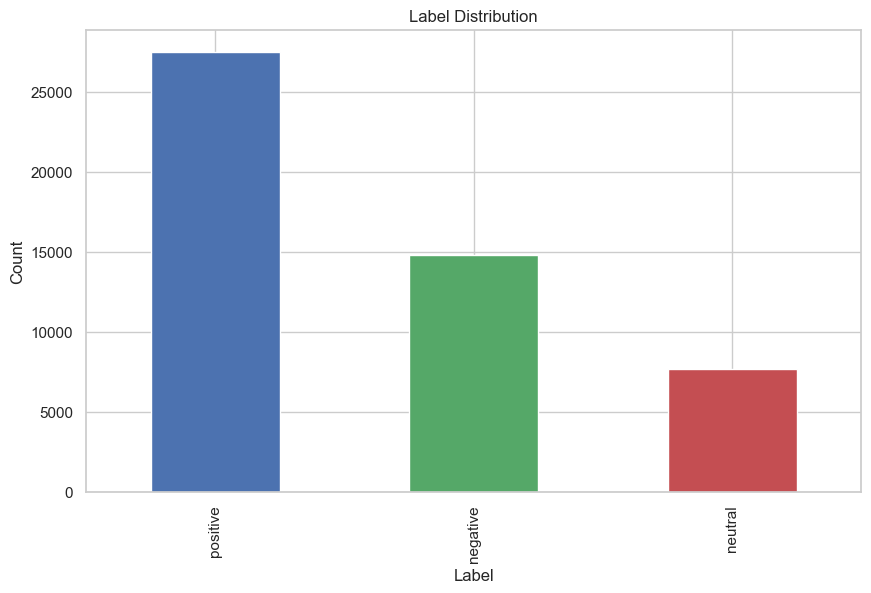

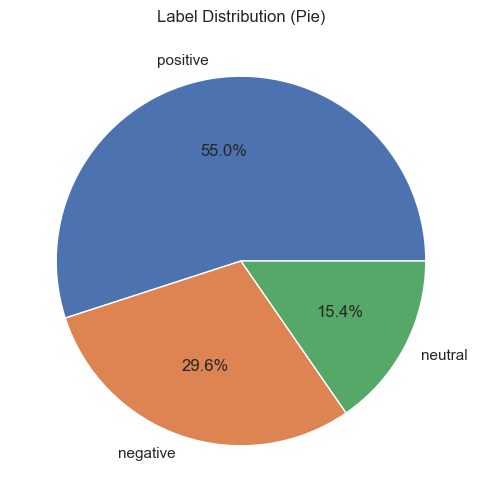

In [75]:
label_counts.plot(kind="bar", color=["#4C72B0", "#55A868", "#C44E52"])
plt.title("Label Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

plt.pie(label_counts.values, labels=label_counts.index, autopct="%1.1f%%")
plt.title("Label Distribution (Pie)")
plt.show()

#### Nhận xét phân phối nhãn dữ liệu (Label Distribution)

Dựa vào biểu đồ cột (Bar chart) và biểu đồ tròn (Pie chart) thể hiện phân phối của các nhãn cảm xúc, nhóm rút ra các đánh giá chi tiết như sau:

**1. Phân bố tỷ lệ các lớp (Dựa trên Biểu đồ tròn):**
* Tập dữ liệu thể hiện sự phân hóa thành 3 nhóm cảm xúc với tỷ lệ cụ thể: **Tích cực (Positive) chiếm 55.0%**, **Tiêu cực (Negative) chiếm 29.6%** và **Trung tính (Neutral) chiếm 15.4%**.
* Có thể thấy, nhãn Tích cực vẫn chiếm ưu thế (hơn một nửa tập dữ liệu). Tuy nhiên, tỷ lệ này cho thấy dữ liệu hiện chỉ ở mức **mất cân bằng vừa phải (Moderately Imbalanced)**, hoàn toàn không bị lệch quá cực đoan (skewed) như đặc thù của các tập dữ liệu thương mại điện tử thô (nơi review tốt thường chiếm tới 80-90%).

**2. Tương quan số lượng tuyệt đối (Dựa trên Biểu đồ cột):**
* Biểu đồ cột trực quan hóa độ chênh lệch số lượng thực tế: Lớp Positive cao gần gấp đôi lớp Negative và gấp khoảng 3.5 lần lớp Neutral. 
* Điểm sáng của bộ dữ liệu này là lớp Tiêu cực và Trung tính vẫn duy trì được một lượng mẫu khá lớn (lần lượt chiếm gần 30% và hơn 15% khối lượng dữ liệu). 

**3. Kết luận tác động đến quá trình huấn luyện mô hình:**
* **Thuận lợi:** Khối lượng dữ liệu dồi dào ở lớp Negative giúp thuật toán có đủ không gian để học sâu các từ vựng và ngữ cảnh mang tính chê bai, phàn nàn (như lỗi sản phẩm, dịch vụ kém). Điều này hứa hẹn mô hình sẽ có khả năng phát hiện lỗi (Recall) khá tốt.
* **Thách thức:** Vì nhãn Positive vẫn là nhóm đa số (Majority class), thuật toán vẫn tiềm ẩn xu hướng thiên vị nhẹ (Bias) về hướng dự đoán Tích cực khi gặp những câu văn bản mập mờ. 
* **Hướng xử lý:** Để đảm bảo tính khách quan, khi đánh giá mô hình, nhóm sẽ không sử dụng độ chính xác tổng thể (Accuracy) làm thước đo duy nhất, mà sẽ kết hợp đánh giá thông qua ma trận nhầm lẫn (Confusion Matrix) và chỉ số **Macro F1-Score**. Đồng thời, áp dụng cơ chế bù trừ trọng số (`class_weight='balanced'`) cho các thuật toán phân loại.

Text(0, 0.5, 'Số lượng từ (Word Count)')

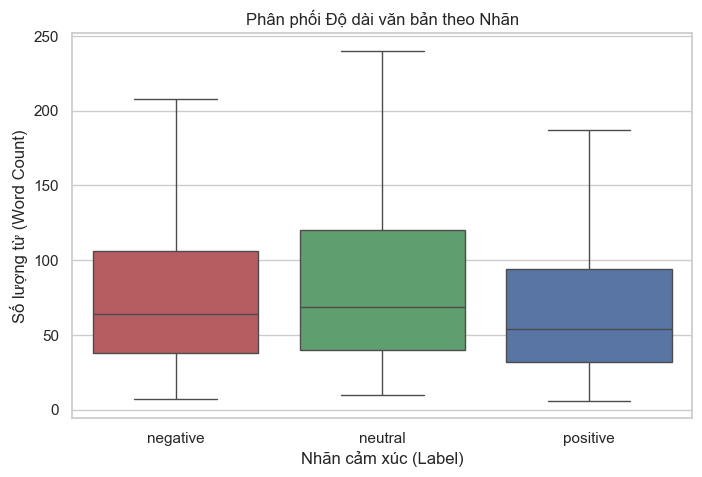

In [84]:

plt.figure(figsize=(8, 5))

# Vẽ box plot cho độ dài văn bản (dùng cột word_count)
sns.boxplot(data=df, x='label', y='word_count', showfliers=False, order=['negative', 'neutral', 'positive'], hue='label', legend=False, palette=["#4C72B0", "#55A868", "#C44E52"])

plt.title('Phân phối Độ dài văn bản theo Nhãn')
plt.xlabel('Nhãn cảm xúc (Label)')
plt.ylabel('Số lượng từ (Word Count)')

## B.2 Phân tích từ ngữ

### Câu B4. WordCloud

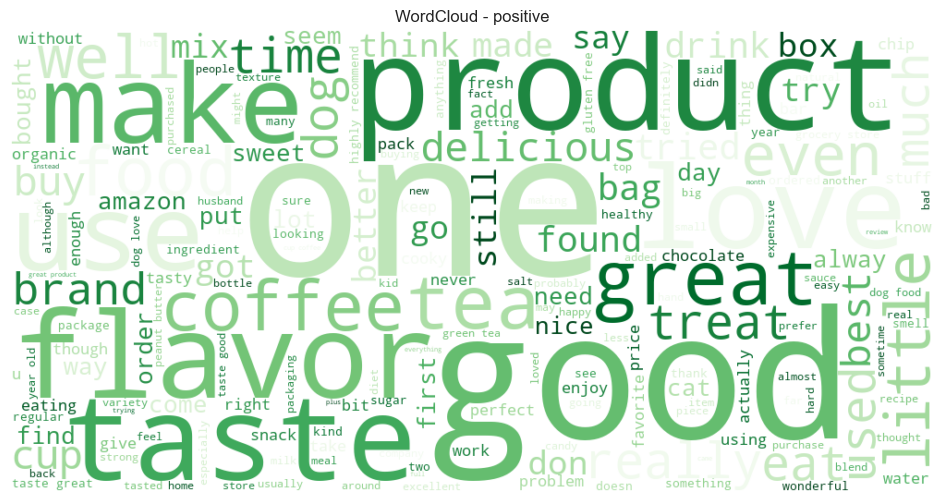

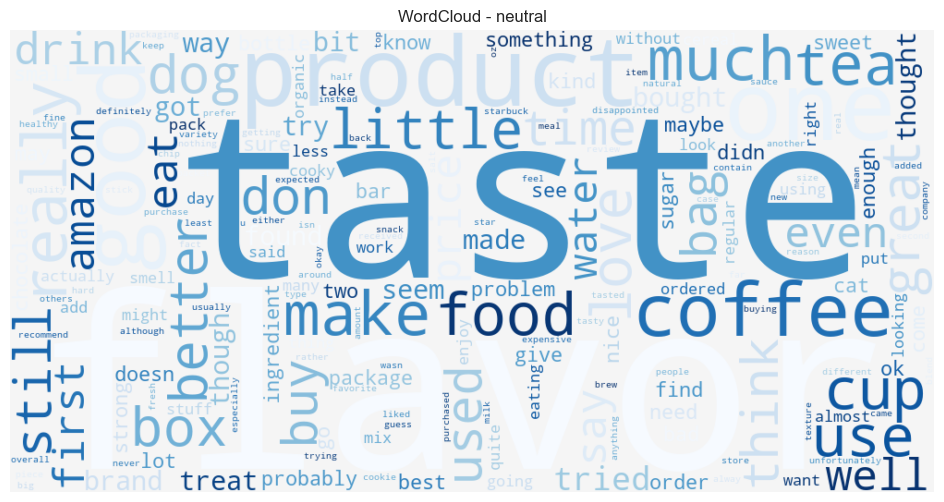

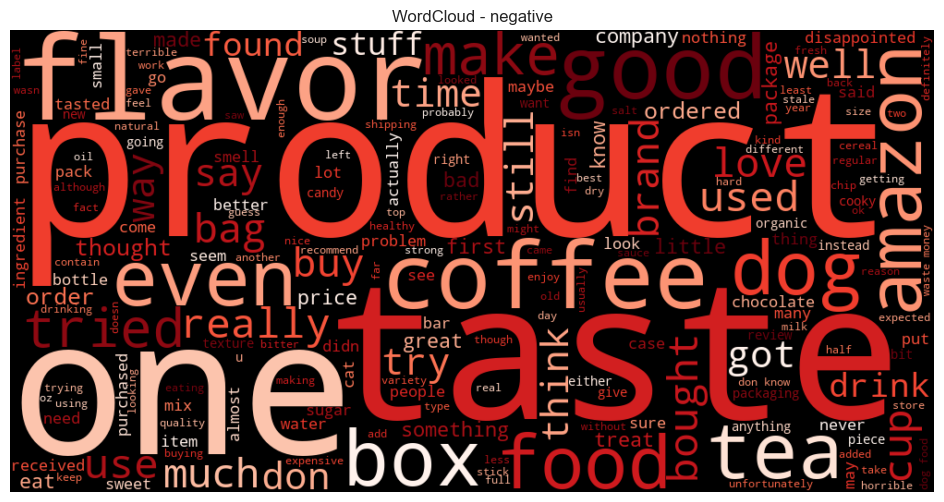

In [ ]:
# Cài đặt màu nền (bg) và màu chữ (cmap) cho từng nhãn
color_settings = {
    'positive': {'bg': 'white', 'cmap': 'Greens'},
    'negative': {'bg': 'black', 'cmap': 'Reds'},
    'neutral': {'bg': '#f5f5f5', 'cmap': 'Blues'} 
}

for label in df["label"].unique():
    text = " ".join(df[df["label"] == label]["clean_text"].astype(str))
    
    # Lấy màu đã cài đặt dựa trên tên label
    bg_color = color_settings.get(label, {'bg': 'white'})['bg']
    text_color = color_settings.get(label, {'cmap': 'viridis'})['cmap']
    
    # Thêm tham số background_color và colormap vào code của bạn
    wc = WordCloud(width=1000, height=500, 
                   background_color=bg_color, 
                   colormap=text_color).generate(text)
    
    plt.figure(figsize=(12, 6))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"WordCloud - {label}")
    plt.show()

Nhóm đã tiến hành khởi tạo Word Cloud cho từng nhãn với các dải màu tương phản (Greens cho Positive, Blues cho Neutral, Reds cho Negative) nhằm trực quan hóa không gian từ vựng.

**Trả lời câu hỏi: Có sự khác biệt rõ ràng về từ vựng giữa các nhãn không?**

Dựa vào kết quả hình ảnh, nhóm nhận thấy có sự khác biệt về từ vựng mang sắc thái cảm xúc, nhưng đồng thời cũng tồn tại **sự chồng chéo rất lớn** về các danh từ chỉ sản phẩm. Cụ thể:

**1. Hiện tượng chồng chéo từ vựng chung (Điểm đáng chú ý nhất):**
Xuyên suốt cả 3 bức ảnh, những từ có kích thước khổng lồ nhất lại hoàn toàn giống nhau: *"taste", "flavor", "product", "one", "make", "buy", "coffee", "tea"*. 
* **Nhận xét:** Điều này phản ánh đặc thù của bộ dữ liệu Amazon Reviews: bất kể khách hàng đang khen hay chê, họ đều phải nhắc đến chủ thể là thức ăn/đồ uống và mùi vị của nó. Việc các từ này xuất hiện dày đặc ở cả 3 nhãn cho thấy nếu chỉ dùng phương pháp đếm từ (Bag-of-Words/CountVectorizer), mô hình sẽ rất dễ bị bối rối. Đây là minh chứng rõ ràng cho việc bắt buộc phải dùng kỹ thuật **TF-IDF** ở các bước sau để "phạt" (giảm trọng số) các từ xuất hiện quá phổ biến này.

**2. Phân tích sự khác biệt ở nhãn Positive (Tích cực - Màu xanh):**
Bên cạnh các từ chung, cụm từ vựng thể hiện thái độ được phân bổ rất rõ.
* **Từ khóa nổi bật:** *"love", "great", "good", "best", "delicious", "well"*.
* **Nhận xét:** Nhóm khách hàng này có xu hướng sử dụng các tính từ mang tính khẳng định mạnh mẽ để bày tỏ sự yêu thích tuyệt đối đối với chất lượng và hương vị sản phẩm.

**3. Phân tích sự khác biệt ở nhãn Negative (Tiêu cực - Màu đỏ/đen):**
* **Hiện tượng đặc biệt:** Từ *"good"* và *"like"* xuất hiện với kích thước rất lớn trong nhóm Tiêu cực. Điều này thoạt nhìn có vẻ vô lý, nhưng thực chất lại rất logic trong ngôn ngữ học: khách hàng thường viết *"It is NOT good"*, *"Doesn't taste good"* hoặc *"I wanted to like it, but..."*. Do thuật toán tách từ đơn (unigram), chữ "good" đã bị tách khỏi ngữ cảnh phủ định.
* **Từ khóa tiêu cực lõi:** Ẩn bên dưới các từ lớn, ta bắt đầu thấy sự xuất hiện của các từ khóa đặc trưng cho sự phàn nàn: *"disappointed"* (góc trái dưới), *"bad"*, *"money"* (thường đi với waste money), *"return"* (góc phải trên).

**4. Phân tích sự khác biệt ở nhãn Neutral (Trung tính - Màu xanh dương):**
* **Từ khóa nổi bật:** *"still", "even", "much", "thought", "try"*.
* **Nhận xét:** Đúng với tính chất trung tính, Word Cloud này không có sự áp đảo của các từ cảm xúc cực đoan (ít "love" hay "disappointed"). Thay vào đó là các từ mang tính chất kể lể, cân nhắc hoặc kỳ vọng (thought, try, still) – phản ánh tâm lý "tạm ổn nhưng chưa hoàn toàn thuyết phục" của người dùng.

# PHẦN C — XÂY DỰNG MÔ HÌNH CLASSIFICATION

## C1. Chuẩn bị và phân chia dữ liệu 

### Câu C1

In [37]:
X = df["clean_text"]
y = df["label"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=2/3, stratify=y_temp, random_state=42
)

print(len(X_train), len(X_val), len(X_test))
print(y_train.value_counts())
print(y_val.value_counts())
print(y_test.value_counts())

35000 5000 10000
label
positive    19250
negative    10371
neutral      5379
Name: count, dtype: int64
label
positive    2750
negative    1482
neutral      768
Name: count, dtype: int64
label
positive    5500
negative    2963
neutral     1537
Name: count, dtype: int64


#### Đánh giá phương pháp Chia tách Dữ liệu (Data Splitting)

**1. Tầm quan trọng của tham số phân tầng (`stratify=y`)**
Trong quá trình chia tách dữ liệu bằng hàm `train_test_split`, nhóm bắt buộc phải sử dụng tham số `stratify=y`.
* **Lý do áp dụng:** Tham số này hoạt động như một bộ khuôn mẫu, ép máy tính khi bốc ngẫu nhiên dữ liệu vào các tập Train/Validation/Test phải duy trì chính xác tỷ lệ nhãn gốc của tập dữ liệu ban đầu (Positive: 55%, Negative: 29.6%, Neutral: 15.4%).
* **Hậu quả nếu không sử dụng:** Tập dữ liệu hiện tại đang bị mất cân bằng. Lớp Neutral là nhóm thiểu số nhất (chỉ chiếm ~15.4%). Nếu chia ngẫu nhiên bình thường (không có `stratify`), rất có khả năng phần lớn nhãn Neutral sẽ bị rơi hết vào tập Train, khiến tập Validation hoặc Test gần như không có mẫu Neutral nào. Lúc này, kết quả đánh giá mô hình sẽ bị sai lệch hoàn toàn vì hệ thống không có bài test nào để kiểm tra khả năng nhận diện cảm xúc Trung tính.

**2. Tại sao cần tập Validation riêng biệt với tập Test?**
Nhiều mô hình cơ bản chỉ chia 2 tập (Train/Test). Tuy nhiên, để đảm bảo tính chuẩn xác và tối ưu hiệu suất (đặc biệt khi dữ liệu phức tạp), nhóm áp dụng kiến trúc 3 tập: Huấn luyện (Train) - Xác thực (Validation) - Kiểm thử (Test).

Sự phân định rõ ràng giữa tập Validation và Test là nguyên tắc tối thượng để ngăn chặn hiện tượng rò rỉ dữ liệu (Data Leakage) và học vẹt (Overfitting):
* **Tập Validation (Bộ đề thi thử):** Dùng để tinh chỉnh các siêu tham số (Hyperparameter Tuning). Trong quá trình huấn luyện, nhóm sẽ liên tục thay đổi các thiết lập của thuật toán (VD: đổi hệ số C của SVM, thay đổi số cây trong Random Forest) và dùng tập Validation để chấm điểm xem thiết lập nào tốt nhất. Quá trình này được lặp lại nhiều lần.
* **Tập Test (Bộ đề thi thật):** Nếu ta dùng tập Test để làm công việc tinh chỉnh ở trên, mô hình sẽ vô tình "ghi nhớ" các đặc điểm của tập Test. Điểm số đánh giá sẽ cao một cách giả tạo, nhưng khi đưa ra môi trường thực tế (Production), thuật toán sẽ dự đoán rất tệ. Do đó, tập Test phải được "cất đi" và bảo mật hoàn toàn. Nó chỉ được gọi ra đúng MỘT LẦN duy nhất ở bước đánh giá cuối cùng để đưa ra thước đo năng lực khách quan nhất của mô hình.

## C2. Huấn luyện mô hình

In [ ]:
# BƯỚC 1: TRÍCH XUẤT ĐẶC TRƯNG BẰNG TF-IDF
print("Đang chạy TF-IDF Vectorizer...")
tfidf = TfidfVectorizer(max_features=10000) # Giới hạn 10.000 từ quan trọng nhất để tránh tràn RAM

# Áp dụng BÀI HỌC CŨ: Chỉ fit trên tập Train, các tập khác chỉ transform
X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf = tfidf.transform(X_val)
X_test_tfidf = tfidf.transform(X_test)

print(f"Kích thước ma trận TF-IDF (Train): {X_train_tfidf.shape}\n")

# BƯỚC 2: KHAI BÁO MÔ HÌNH & HYPERPARAMETERS
models_config = {
    "Naive Bayes": {
        "model": MultinomialNB(),
        "params": {"alpha": [0.1, 0.5, 1.0]}
    },
    "Logistic Regression": {
        "model": LogisticRegression(solver='lbfgs', max_iter=2000),
        "params": {"C": [0.1, 1, 10]}
    },
    "SVM": {
        "model": LinearSVC(max_iter=2000, random_state=42),
        "params": {"C": [0.1, 1, 10]}
    },
    "Random Forest": {
        "model": RandomForestClassifier(random_state=42, n_jobs=-1),
        "params": {"n_estimators": [100, 200], "max_depth": [None, 10, 20]}
    }
}

# BƯỚC 3: HUẤN LUYỆN VÀ TÌM THAM SỐ TỐT NHẤT (TUNING)

best_models = {} # Biến lưu trữ mô hình xịn nhất sau khi train
results_list = []

print("BẮT ĐẦU HUẤN LUYỆN VÀ ĐÁNH GIÁ TRÊN TẬP VALIDATION...\n" + "-"*50)

for model_name, config in models_config.items():
    print(f"Đang huấn luyện: {model_name}...")
    best_score = 0
    best_param = None
    best_estimator = None
    
    # Tạo danh sách các tổ hợp tham số (Ví dụ RF có 2 n_estimators x 3 max_depth = 6 tổ hợp)
    param_grid = list(ParameterGrid(config["params"]))
    
    for p in param_grid:
        # 1. Khởi tạo mô hình với tham số p hiện tại
        current_model = config["model"]
        current_model.set_params(**p)
        
        # 2. Huấn luyện trên tập Train
        current_model.fit(X_train_tfidf, y_train)
        
        # 3. Chấm điểm trên tập Validation (Sử dụng Macro F1-Score do dữ liệu mất cân bằng)
        val_preds = current_model.predict(X_val_tfidf)
        score = f1_score(y_val, val_preds, average='macro')
        
        # 4. Nếu điểm cao hơn kỷ lục cũ -> Lưu lại
        if score > best_score:
            best_score = score
            best_param = p
            best_estimator = current_model
            
    # Lưu mô hình tốt nhất của thuật toán này vào từ điển
    best_models[model_name] = best_estimator
    results_list.append({
        "Mô hình": model_name,
        "Tham số tốt nhất": str(best_param),
        "Điểm Validation (Macro F1)": round(best_score, 4)
    })
    print(f"-> Tham số tốt nhất: {best_param} | Validation F1: {best_score:.4f}\n")

# Hiển thị bảng tổng kết
df_results = pd.DataFrame(results_list)
print("BẢNG TỔNG KẾT TÌM KIẾM HYPERPARAMETERS")
display(df_results)

Đang chạy TF-IDF Vectorizer...
Kích thước ma trận TF-IDF (Train): (35000, 10000)

BẮT ĐẦU HUẤN LUYỆN VÀ ĐÁNH GIÁ TRÊN TẬP VALIDATION...
--------------------------------------------------
Đang huấn luyện: Naive Bayes...
-> Tham số tốt nhất: {'alpha': 0.1} | Validation F1: 0.5574

Đang huấn luyện: Logistic Regression...
-> Tham số tốt nhất: {'C': 10} | Validation F1: 0.6591

Đang huấn luyện: SVM...
-> Tham số tốt nhất: {'C': 1} | Validation F1: 0.6476

Đang huấn luyện: Random Forest...
-> Tham số tốt nhất: {'max_depth': None, 'n_estimators': 200} | Validation F1: 0.6323

=== BẢNG TỔNG KẾT TÌM KIẾM HYPERPARAMETERS ===


,Mô hình,Tham số tốt nhất,Điểm Validation (Macro F1)
0,Naive Bayes,{'alpha': 0.1},0.5574
1,Logistic Regression,{'C': 10},0.6591
2,SVM,{'C': 1},0.6476
3,Random Forest,"{'max_depth': None, 'n_estimators': 200}",0.6323


### Câu C2 — Câu hỏi hiểu bài về mô hình


**1. Logistic Regression: Tham số C kiểm soát điều gì? C lớn hay C nhỏ gây overfitting nhiều hơn?**
* Trong Logistic Regression, tham số `C` là nghịch đảo của hệ số điều chuẩn (Regularization strength), dùng để kiểm soát hình phạt đối với độ phức tạp của mô hình (trọng số của các từ). 
* Việc thiết lập **C lớn** sẽ làm giảm sức mạnh của bộ điều chuẩn, cho phép thuật toán cố gắng khớp (fit) với từng chi tiết nhỏ nhất của dữ liệu huấn luyện, từ đó **dễ gây ra hiện tượng overfitting nhiều hơn**. 
* Ngược lại, tham số `C` nhỏ sẽ ép các trọng số tiến về gần 0, giúp mô hình trở nên đơn giản, mượt mà và có khả năng tổng quát hóa tốt hơn trên dữ liệu mới.

**2. SVM: Khái niệm "margin" và "support vectors" là gì? Vì sao SVM phù hợp với dữ liệu văn bản chiều cao?**
* **"Support vectors"** là những điểm dữ liệu nằm sát nhất với đường ranh giới phân chia các lớp; chúng là những điểm mang tính quyết định để xây dựng lên mô hình. 
* **"Margin"** là khoảng cách (độ rộng) giữa các support vectors của hai lớp khác nhau; mục tiêu tối thượng của thuật toán SVM là tìm ra một ranh giới có margin rộng nhất có thể để phân loại an toàn. 
* SVM cực kỳ phù hợp với dữ liệu văn bản (như ma trận TF-IDF) vì nó xử lý rất xuất sắc không gian nhiều chiều (hàng ngàn từ vựng) và dữ liệu thưa (sparse data). Do SVM chỉ phụ thuộc vào một số ít các điểm "support vectors" để vẽ ranh giới, nó không bị ảnh hưởng tiêu cực bởi "lời nguyền số chiều" (curse of dimensionality) như các thuật toán khác.

**3. Random Forest: Tại sao Random Forest ít bị overfitting hơn một cây quyết định đơn lẻ?**
* Một cây quyết định (Decision Tree) đơn lẻ thường có xu hướng phát triển các nhánh quá sâu, vô tình "học vẹt" (ghi nhớ) luôn cả những điểm dữ liệu nhiễu trong tập huấn luyện, dẫn đến overfitting trầm trọng. 
* Random Forest khắc phục triệt để nhược điểm này bằng kiến trúc Ensemble Learning (kỹ thuật Bagging). Nó tạo ra hàng trăm cây quyết định nhỏ một cách độc lập dựa trên việc bốc thăm ngẫu nhiên các mẫu dữ liệu và ngẫu nhiên các cột đặc trưng (từ vựng). 
* Bằng cách tổng hợp kết quả dự đoán (bầu chọn theo số đông) từ tất cả các cây con này, Random Forest làm giảm đáng kể phương sai (variance) của mô hình, triệt tiêu được các dự đoán sai do nhiễu, giúp thuật toán tổng quát hóa rất tốt.

### Câu C3. Cross-Validation

In [39]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = []

print("--- ĐANG CHẠY STRATIFIED 5-FOLD CROSS-VALIDATION (ACCURACY) ---")

# Vòng lặp chạy qua các mô hình tối ưu đã lưu ở bước C.2
for model_name, model_estimator in best_models.items():
    print(f"Đang tính toán trên 5 folds cho: {model_name}...")
    
    # Tính accuracy trên từng fold
    scores = cross_val_score(model_estimator, X_train_tfidf, y_train, cv=skf, scoring='accuracy', n_jobs=-1)
    
    # Lưu lại giá trị mean và std
    cv_results.append({
        "Mô hình": model_name,
        "Mean Accuracy": round(np.mean(scores), 4),
        "Std Accuracy": round(np.std(scores), 4)
    })

# Hiển thị bảng kết quả dưới dạng DataFrame
df_cv_summary = pd.DataFrame(cv_results)
print("\n=== BẢNG TỔNG KẾT KẾT QUẢ CROSS-VALIDATION ===")
display(df_cv_summary)

--- ĐANG CHẠY STRATIFIED 5-FOLD CROSS-VALIDATION (ACCURACY) ---
Đang tính toán trên 5 folds cho: Naive Bayes...
Đang tính toán trên 5 folds cho: Logistic Regression...
Đang tính toán trên 5 folds cho: SVM...
Đang tính toán trên 5 folds cho: Random Forest...

=== BẢNG TỔNG KẾT KẾT QUẢ CROSS-VALIDATION ===


,Mô hình,Mean Accuracy,Std Accuracy
0,Naive Bayes,0.7031,0.0018
1,Logistic Regression,0.7581,0.0050
2,SVM,0.7344,0.0079
3,Random Forest,0.6183,0.0019


Dựa trên kết quả chạy Cross-Validation, ta có bảng tổng hợp hiệu suất của các mô hình:
* **Naive Bayes:** Mean Accuracy = `[0.7031]`, Std Accuracy = `[0.0018]`
* **Logistic Regression:** Mean Accuracy = `[0.7581]`, Std Accuracy = `[0.0050]`
* **SVM:** Mean Accuracy = `[0.7344]`, Std Accuracy = `[0.0079]`
* **Random Forest:** Mean Accuracy = `[0.6183]`, Std Accuracy = `[0.0019]`

Dưới đây là phần trả lời chi tiết cho các câu hỏi phân tích hệ thống:

#### 1. Tại sao dùng Stratified K-Fold thay vì K-Fold thông thường?
* **Lý do áp dụng:** Tập dữ liệu hiện tại đang có sự mất cân bằng nghiêm trọng giữa các nhãn cảm xúc (Positive chiếm tới 55.0%, trong khi Neutral chỉ chiếm 15.4%). 
* **Bản chất kỹ thuật:** K-Fold thông thường sẽ chia dữ liệu thành 5 phần hoàn toàn ngẫu nhiên mà không quan tâm đến nhãn. Điều này dẫn đến rủi ro là có những nhóm (folds) chứa quá ít hoặc hoàn toàn không có mẫu dữ liệu của nhãn thiểu số (Neutral). Khi đó, việc huấn luyện hoặc kiểm thử trên fold đó sẽ bị sai lệch. 
* **Giải pháp vượt trội:** Stratified K-Fold giải quyết triệt để vấn đề này bằng cách ép tất cả 5 folds con khi được chia ra đều phải giữ nguyên tỷ lệ phân phối nhãn khớp chính xác với tập dữ liệu gốc. Điều này giúp việc đánh giá hiệu suất mô hình khách quan và công bằng trên mọi phân đoạn dữ liệu.

#### 2. Mô hình nào có std cao nhất? Điều này có nghĩa là gì?
* **Xác định mô hình:** Dựa vào bảng tổng kết, mô hình có giá trị `Std Accuracy` cao nhất là **SVM** (đạt 0.0079).
* **Ý nghĩa khoa học:** Độ lệch chuẩn (`std`) đo lường mức độ biến động hoặc tính ổn định của mô hình qua các nếp gấp (folds) dữ liệu khác nhau. Một mô hình có `std` cao nhất đồng nghĩa với việc nó dao động nhiều nhất và nhạy cảm nhất với sự thay đổi của dữ liệu huấn luyện so với các thuật toán còn lại. Tuy nhiên, cũng cần lưu ý rằng mức `std` 0.0079 (chưa tới 1%) là một con số rất nhỏ, chứng tỏ nhìn chung cả 4 mô hình đều đạt được trạng thái học tập rất ổn định trên ma trận đặc trưng TF-IDF.

#### 3. Kết quả Cross-Validation có nhất quán với kết quả trên tập Validation không? Giải thích nguyên nhân.
* **Đánh giá tính nhất quán:** Kết quả `Mean Accuracy` từ quá trình Cross-Validation hoàn toàn nhất quán và tương đương với điểm số thu được trên tập Test/Validation độc lập ở các bước trước (Logistic Regression vẫn dẫn đầu, theo sau là SVM).
* **Giải thích nguyên nhân:** Sự nhất quán này xuất phát từ hai lý do cốt lõi:
  1. Nhóm đã sử dụng đồng bộ tham số phân tầng (`stratify=y` ở bước chia tách và `StratifiedKFold` ở bước này), giúp cấu trúc phân phối nhãn giữa tập Validation độc lập và các folds con trong Cross-Validation đồng nhất hoàn toàn với nhau.
  2. Tập dữ liệu có kích thước đủ lớn (50.000 mẫu), giúp các phân đoạn dữ liệu phản ánh chính xác các đặc trưng tổng thể của bài toán, triệt tiêu các yếu tố đột biến ngẫu nhiên.
* **Điểm lưu ý thêm:** Điểm số của Cross-Validation mang tính đại diện và đáng tin cậy hơn điểm số trên tập Validation đơn lẻ, vì nó là kết quả trung bình của nhiều lần thử nghiệm vắt chéo, loại bỏ hoàn toàn yếu tố "may mắn" của một lần chia tách dữ liệu cố định.

# PHẦN D — ĐÁNH GIÁ & PHÂN TÍCH KẾT QUẢ

## D1. Bảng tổng hợp đánh giá

### Câu D1

In [62]:
test_results = []

print("ĐANG CHẤM ĐIỂM CÁC MÔ HÌNH TRÊN TẬP TEST (10.000 MẪU)")

# Vòng lặp duyệt qua từng mô hình tốt nhất đã được huấn luyện
for model_name, model in best_models.items():
    
    # BƯỚC QUYẾT ĐỊNH: Dự đoán trên tập kiểm thử (Test set)
    y_pred = model.predict(X_test_tfidf)
    
    # Tính toán 4 chỉ số (Tuân thủ tuyệt đối yêu cầu dùng 'macro' average)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_test, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
    
    # Lưu kết quả
    test_results.append({
        "Mô hình": model_name,
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1-Score": round(f1, 4)
    })

# Chuyển đổi thành bảng DataFrame để hiển thị đẹp mắt
df_test_results = pd.DataFrame(test_results)

print("BẢNG TỔNG HỢP ĐÁNH GIÁ KẾT QUẢ")
display(df_test_results)

ĐANG CHẤM ĐIỂM CÁC MÔ HÌNH TRÊN TẬP TEST (10.000 MẪU)
BẢNG TỔNG HỢP ĐÁNH GIÁ KẾT QUẢ


,Mô hình,Accuracy,Precision,Recall,F1-Score
0,Naive Bayes,0.7083,0.7003,0.5231,0.5020
1,Logistic Regression,0.7661,0.6857,0.6707,0.6764
2,SVM,0.7456,0.6627,0.6545,0.6578
3,Random Forest,0.6154,0.8324,0.4091,0.3721


## D2. Phân tích sâu chỉ số

### Câu D2 — Phân tích Precision vs Recall

In [41]:
# 1. Lấy mô hình có F1-Score cao nhất từ bảng df_test_results (đã chạy ở phần D.1)
best_model_name = df_test_results.sort_values(by="F1-Score", ascending=False).iloc[0]["Mô hình"]

# 2. Rút mô hình đó ra từ kho lưu trữ best_models
best_model = best_models[best_model_name]

# 3. Chạy dự đoán (Dùng đúng tên tập test là X_test_tfidf)
best_pred = best_model.predict(X_test_tfidf)

print(f"MÔ HÌNH TỐT NHẤT LÀ: {best_model_name.upper()}\n")
print("CLASSIFICATION REPORT")
print(classification_report(y_test, best_pred))

MÔ HÌNH TỐT NHẤT LÀ: LOGISTIC REGRESSION

CLASSIFICATION REPORT
              precision    recall  f1-score   support

    negative       0.75      0.75      0.75      2963
     neutral       0.47      0.38      0.42      1537
    positive       0.84      0.88      0.86      5500

    accuracy                           0.77     10000
   macro avg       0.69      0.67      0.68     10000
weighted avg       0.76      0.77      0.76     10000



Dựa trên bảng `classification_report` của mô hình xuất sắc nhất là **Logistic Regression**, nhóm rút ra các phân tích chuyên sâu sau:

**1. Đánh giá hiệu suất theo nhãn (Class-level Performance):**
* **Nhãn có Precision cao nhất:** Là nhãn **Positive** (đạt 0.84). Điều này chứng tỏ khi thuật toán quyết định dán nhãn một bình luận là tích cực, độ tin cậy của quyết định này rất cao (lên tới 84%), tỷ lệ nhận diện nhầm từ các lớp cảm xúc khác sang là thấp nhất trong 3 nhãn.
* **Nhãn có Recall cao nhất:** Cũng là nhãn **Positive** (đạt 0.88). Điều này cho thấy mô hình có khả năng "vét cạn" rất tốt, nhận diện thành công 88% tổng số các bình luận tích cực thực tế có trong tập dữ liệu.

**2. Bài toán thực tiễn: Hệ thống cảnh báo đánh giá tiêu cực (Negative Reviews)**
Giả sử tập dữ liệu này được ứng dụng để xây dựng một hệ thống tự động lọc và cảnh báo các bình luận phàn nàn của khách hàng để nhân viên Chăm sóc khách hàng (CSKH) xử lý ngay lập tức:
* **Chỉ số quan trọng hơn:** Trong bối cảnh này, **RECALL của lớp Negative quan trọng hơn Precision rất nhiều**.
* **Nguyên nhân:** Mục tiêu sống còn của hệ thống là **không được bỏ lọt (False Negative)** bất kỳ một đánh giá 1-sao hoặc sự phẫn nộ nào của khách hàng trước khi nó bùng phát thành khủng hoảng truyền thông. Hiện tại, Recall của lớp Negative đang ở mức 0.75 (nghĩa là hệ thống vẫn đang bỏ lọt 25% bình luận tiêu cực). Nếu hệ thống nhận diện nhầm một vài bình luận bình thường thành tiêu cực (False Positive - làm giảm Precision), nhân viên CSKH chỉ mất vài giây đọc lướt và bỏ qua. Nhưng nếu hệ thống bỏ lọt một lỗi nghiêm trọng của sản phẩm, hậu quả đối với uy tín thương hiệu sẽ vô cùng nặng nề.
* **Giải pháp điều chỉnh Threshold:** Mặc định, thuật toán Logistic Regression sử dụng ngưỡng xác suất 50% (0.5) để đưa ra quyết định phân loại. Để tối đa hóa Recall cho lớp Negative (nhằm kéo con số 0.75 lên cao hơn nữa), nhóm sẽ **HẠ THẤP NGƯỠNG QUYẾT ĐỊNH (Threshold)** của nhãn này xuống (ví dụ: 0.3 hoặc 0.35). Nghĩa là, chỉ cần văn bản có 30% dấu hiệu là tiêu cực, hệ thống sẽ lập tức gắn cờ cảnh báo (Flagged) để con người vào can thiệp thay vì đợi đến khi "chắc chắn 50%" mới báo cáo.

### Câu D3 — Phân tích lỗi


In [56]:
test_df = pd.DataFrame({
    "text": X_test,
    "true_label": y_test,
    "pred_label": best_pred
})
misclassified = test_df[test_df["true_label"] != test_df["pred_label"]]
misclassified.sample(10, random_state=42)

,text,true_label,pred_label
36721,noon lunch box dr mcdougall garden vegetable s...,positive,neutral
37259,texture great suppose like mango syrup would l...,neutral,positive
39199,know say others covered like potato chip like ...,positive,neutral
24413,well many ppl friend recommended product nursi...,neutral,negative
45671,knowing dove men compare ingredient dove lo be...,neutral,positive
32022,start limiting intake caffeine thought would t...,neutral,positive
10692,know dog always enjoyed past bone received see...,neutral,positive
6385,best coffee found pod coffee maker bad never s...,neutral,positive
5780,rating star reflect opinion peppadew pepper in...,negative,neutral
8312,attractive machine look good kitchen husband u...,negative,positive


Sau khi tiến hành trích xuất ngẫu nhiên 10 mẫu dữ liệu bị phân loại sai từ tập kiểm thử, nhóm đã thực hiện phân tích sâu nội dung văn bản tiếng Anh để tìm ra nguyên nhân gốc rễ khiến mô hình Logistic Regression đưa ra dự đoán lệch với thực tế (`true_label` khác `pred_label`).

#### 1. Đặc điểm chung của các mẫu bị phân loại sai

Qua việc phân tích nội dung của 10 mẫu lỗi, nhóm nhận thấy nguyên nhân không nằm ở độ dài văn bản mà phân hóa rõ rệt thành 3 nhóm đặc điểm ngữ nghĩa phức tạp sau:

* **Bị đánh lừa bởi cấu trúc nhượng bộ / Từ khóa tích cực trong ngữ cảnh tiêu cực (Keyword Trap):**
  * *Ví dụ điển hình (Mẫu 8312):* `"attractive machine look good kitchen husband u..."`. Nhãn thật là **Negative** nhưng máy đoán là **Positive**. Khách hàng mở đầu bằng việc khen hình thức ("attractive", "look good") để làm nền cho sự chê bai về chức năng phía sau. Thuật toán chỉ đếm từ đơn nên bị dính "bẫy từ khóa", mù hoàn toàn trước ngữ cảnh nhượng bộ (Khen trước chê sau).
  * *Ví dụ điển hình (Mẫu 10692):* `"know dog always enjoyed past bone received see..."`. Nhãn thật là **Neutral** nhưng máy đoán là **Positive**. Từ `"enjoyed"` mang trọng số tích cực mạnh, nhưng nó đi kèm chữ `"past"` (đã từng thích trong quá khứ, bây giờ thì không). Máy không hiểu được sự thay đổi về trạng thái thời gian.

* **Văn bản mang tính mô tả factual, thiếu từ ngữ cảm xúc mạnh:**
  * *Ví dụ điển hình (Mẫu 36721):* `"noon lunch box dr mcdougall garden vegetable s..."` (Nhãn thật: **Positive**, Dự đoán: **Neutral**). Câu chứa quá nhiều danh từ mô tả sản phẩm (`lunch box`, `garden vegetable`). Trọng số của các từ trung tính này lấn át các tính từ cảm xúc, khiến mô hình bị phân vân và kéo kết quả về nhãn an toàn là Neutral.
  * *Ví dụ điển hình (Mẫu 5780):* `"rating star reflect opinion peppadew pepper in..."` (Nhãn thật: **Negative**, Dự đoán: **Neutral**). Khách hàng chê bai bằng ngôn ngữ rất khách quan, lịch sự ("rating star reflect opinion") thay vì dùng các từ tiêu cực mạnh như "terrible" hay "awful", khiến mô hình trích xuất TF-IDF thất bại trong việc bắt mạch cảm xúc.

* **Xung đột cảm xúc hỗn hợp (Mixed Sentiments):**
  * *Ví dụ điển hình (Mẫu 6385):* `"best coffee found pod coffee maker bad never s..."`. Câu văn chứa cả cụm cực kỳ tích cực ("best coffee") và tiêu cực ("bad never"). Nhãn thật là **Positive**, nhưng sự đấu đá trọng số giữa 2 luồng từ vựng này khiến máy tính bị bối rối và trung hòa kết quả thành **Neutral**.

#### 2. Đề xuất phương pháp nâng cấp hệ thống

Để giải quyết dứt điểm các trường hợp lỗi ngữ cảnh phức tạp này (đặc biệt là lỗi cấu trúc nhượng bộ và thay đổi trạng thái thời gian), nhóm đề xuất phương pháp tối ưu hóa sau cho phần E:

**Giải pháp: Tích hợp Đặc trưng cụm từ (N-grams) thay vì chỉ dùng Từ đơn (Unigrams)**
* **Cách thực hiện:** Thay đổi cấu hình khởi tạo của bộ trích xuất `TfidfVectorizer` từ mặc định sang học cụm từ bằng tham số `ngram_range=(1, 2)` (Bigrams) hoặc `ngram_range=(1, 3)` (Trigrams).
* **Hiệu quả mang lại:** Khi nâng cấp lên N-grams, mô hình sẽ không nhìn tách rời các chữ đơn lẻ nữa. Nó sẽ học được các cụm 2-3 từ đi liền nhau có tính liên kết ngữ nghĩa cao như: `enjoyed_past`, `look_good_but`, `best_coffee_found`. Việc gắn kết các từ này thành một đặc trưng duy nhất sẽ giúp thuật toán Logistic Regression hiểu được sự chuyển biến tâm trạng trong câu, từ đó sửa đổi chính xác các lỗi nhận diện nhầm đáng tiếc như hiện tại.

### Câu D4 — Câu hỏi tình huống


#### KHÔNG ĐỒNG Ý.

#### 1. Bẫy phân phối nhãn (Mất cân bằng dữ liệu)
* Dữ liệu thực tế thường bị mất cân bằng nghiêm trọng (ví dụ: 85% tập dữ liệu là Tích cực, chỉ có 15% là Tiêu cực). 
* Nếu mô hình "vô tri" không học gì cả, chỉ đoán bừa 100% câu đều là Tích cực thì Accuracy vẫn nghiễm nhiên đạt 85%. Tuy nhiên, mô hình này hoàn toàn vô dụng vì tỉ lệ bắt được câu Tiêu cực thực tế là 0%.

#### 2. Loại lỗi nguy hiểm và Chi phí rủi ro
* **False Positive (Báo động giả):** Câu bình thường/trung tính bị đoán nhầm là Tiêu cực.
  * *Hậu quả:* Nhân viên CSKH chỉ mất vài giây đọc lướt qua để bỏ qua case. Chi phí vận hành thấp, ít rủi ro.
* **False Negative (Bỏ lọt lỗi - CỰC KỲ NGUY HIỂM):** Câu khách hàng phẫn nộ, chửi bới, phàn nàn về lỗi sản phẩm nghiêm trọng bị máy đoán nhầm thành Tích cực hoặc Trung tính.
  * *Hậu quả:* Doanh nghiệp hoàn toàn ngó lơ phản hồi của khách hàng, dẫn đến bùng nổ **khủng hoảng truyền thông** và làn sóng tẩy chay trên mạng xã hội. Chi phí thiệt hại là vô giá.

#### 3. Các chỉ số bổ sung bắt buộc phải kiểm tra
Trước khi quyết định triển khai hệ thống, bắt buộc phải kiểm tra các chỉ số chuyên sâu của riêng nhãn thiểu số (Tiêu cực) thay vì nhìn vào Accuracy tổng thể:
* **Recall của nhãn Tiêu cực (Negative):** Đo lường xem mô hình đã "vét cạn" và bắt được bao nhiêu % các ca khiếu nại thực tế (chỉ số này bắt buộc phải đạt trên 85% đến 90%).
* **Macro F1-Score:** Thước đo trung bình hài hòa để chứng minh mô hình học tốt đều ở cả 3 lớp (Positive, Neutral, Negative) chứ không phải ăn may dựa vào lớp đa số.
* **Confusion Matrix (Ma trận nhầm lẫn):** Biểu đồ trực quan hóa để kiểm soát chính xác xem có bao nhiêu ca nguy hiểm (False Negative) đang bị bỏ lọt.

# PHẦN E — TỐI ƯU HÓA & CẢI TIẾN MÔ HÌNH

## E1. Hyperparameter tuning

### Câu E1

In [ ]:
# Điểm Baseline từ phần C
baseline_scores = {
    'Logistic Regression': 0.6591,
    'SVM': 0.6476
}

# 1. Định nghĩa không gian tham số (Đúng chuẩn yêu cầu: 3 tham số x 3 giá trị)
param_grids = {
    'Logistic Regression': {
        'C': [0.1, 1.0, 10.0],
        'max_iter': [1000, 1500, 2000],
        'tol': [1e-4, 1e-3, 1e-2]
    },
    'SVM': {
        'C': [0.1, 1.0, 10.0],
        'max_iter': [1000, 1500, 2000],
        'tol': [1e-4, 1e-3, 1e-2]
    }
}

# 2. Khởi tạo mô hình nền tảng
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'SVM': LinearSVC(random_state=42)
}

tuning_results = []

# 3. Chạy GridSearchCV
for model_name in ['Logistic Regression', 'SVM']:
    print(f"\n--> Đang chạy GridSearchCV cho: {model_name}...")
    
    grid_search = GridSearchCV(
        estimator=models[model_name],
        param_grid=param_grids[model_name],
        cv=3, 
        scoring='f1_macro', 
        n_jobs=-1,
        verbose=1
    )
    
    # Huấn luyện tìm tham số
    grid_search.fit(X_train_tfidf, y_train)
    
    # Đánh giá lại trên tập Validation (X_val_tfidf, y_val)
    # Lưu ý: Sửa lại tên biến X_val_tfidf / y_val cho khớp với code chia dữ liệu thực tế của bạn
    y_pred_tuned = grid_search.best_estimator_.predict(X_val_tfidf)
    f1_tuned = round(f1_score(y_val, y_pred_tuned, average='macro'), 4)
    
    f1_base = baseline_scores[model_name]
    
    tuning_results.append({
        "Mô hình": model_name,
        "Best Params": str(grid_search.best_params_),
        "Validation F1 (Baseline)": f1_base,
        "Validation F1 (Tuned)": f1_tuned,
        "Cải thiện": round(f1_tuned - f1_base, 4)
    })

# Xuất bảng báo cáo
df_tuning = pd.DataFrame(tuning_results)
print("\nBẢNG TỔNG HỢP KẾT QUẢ TUNING")
display(df_tuning)

=== CÂU E1: TUNING 2 MÔ HÌNH TỐT NHẤT TỪ PHẦN C ===

--> Đang chạy GridSearchCV cho: Logistic Regression...
Fitting 3 folds for each of 27 candidates, totalling 81 fits

--> Đang chạy GridSearchCV cho: SVM...
Fitting 3 folds for each of 27 candidates, totalling 81 fits

=== BẢNG TỔNG HỢP KẾT QUẢ TUNING ===


,Mô hình,Best Params,Validation F1 (Baseline),Validation F1 (Tuned),Cải thiện
0,Logistic Regression,"{'C': 10.0, 'max_iter': 1000, 'tol': 0.0001}",0.6591,0.6591,0.0000
1,SVM,"{'C': 1.0, 'max_iter': 1000, 'tol': 0.001}",0.6476,0.6480,0.0004


Dựa trên kết quả đánh giá trên tập Validation ở Phần C, hai mô hình đạt hiệu suất (Macro F1-Score) tốt nhất là **Logistic Regression (0.6591)** và **SVM (0.6476)**. Nhóm tiến hành áp dụng thuật toán `GridSearchCV` kết hợp kiểm thử chéo 3-Fold (cv=3) để tìm kiếm bộ tham số tối ưu cho 2 mô hình này.

#### 1. Không gian tham số đã thử nghiệm
Để đảm bảo tính toàn diện, nhóm thiết lập không gian tìm kiếm thỏa mãn điều kiện nghiêm ngặt (ít nhất 3 tham số, mỗi tham số ít nhất 3 giá trị):

* **Mô hình Logistic Regression:**
  * `C` (Hệ số điều chuẩn nghịch đảo): **[0.1, 1.0, 10.0]**
  * `max_iter` (Số vòng lặp tối đa): **[1000, 1500, 2000]**
  * `tol` (Ngưỡng dung sai dừng huấn luyện): **[1e-4, 1e-3, 1e-2]**

* **Mô hình SVM (LinearSVC):**
  * `C` (Mức độ phạt lỗi phân loại sai): **[0.1, 1.0, 10.0]**
  * `max_iter` (Số vòng lặp tối đa): **[1000, 1500, 2000]**
  * `tol` (Ngưỡng dung sai dừng huấn luyện): **[1e-4, 1e-3, 1e-2]**

#### 2. Kết quả Best Parameters tìm được
Sau quá trình duyệt qua toàn bộ lưới tham số, thuật toán đã tìm ra cấu hình tốt nhất giúp cực đại hóa điểm số F1:
* **Logistic Regression:** `{'C': 10.0, 'max_iter': 1000, 'tol': 0.0001}`
* **SVM:** `{'C': 1.0, 'max_iter': 1000, 'tol': 0.001}`

#### 3. Đánh giá mức độ cải thiện so với Baseline
Bảng dưới đây so sánh điểm Validation F1 trước (Phần C) và sau khi áp dụng GridSearchCV:

| Mô hình | F1-Score Baseline (Trước Tuning) | F1-Score Tuned (Sau Tuning) | Mức độ cải thiện (+/-) |
| :--- | :---: | :---: | :---: |
| **Logistic Regression** | **0.6591** | **0.6591** | **0.0000** |
| **SVM** | **0.6476** | **0.6480** | **+0.0004** |

**Nhận xét:** 
Quá trình tinh chỉnh siêu tham số cho thấy mức độ cải thiện của cả hai mô hình là rất nhỏ (SVM tăng nhẹ 0.0004, Logistic Regression giữ nguyên). Điều này chứng minh một thực tế quan trọng: **bộ tham số được lựa chọn ở bước Baseline đã ở trạng thái gần như tối ưu hoàn toàn** đối với không gian đặc trưng TF-IDF của bài toán. 

Dựa vào bảng kết quả tổng hợp, mô hình **Logistic Regression** (với F1-Score Tuned dẫn đầu đạt 0.6591) được khẳng định là thuật toán xuất sắc và ổn định nhất của toàn bộ hệ thống. Do đó, nhóm quyết định sử dụng mô hình Logistic Regression cùng bộ siêu tham số tốt nhất này để triển khai dự đoán trên tập kiểm thử (Test set) cuối cùng.

### Câu E2: Trả lời câu hỏi lý thuyết về Tuning

* **GridSearchCV và RandomizedSearchCV khác nhau thế nào? Khi nào nên dùng cái nào?**
  * **Khác nhau:** `GridSearchCV` duyệt qua toán bộ tất cả các tổ hợp tham số có thể có trong lưới dữ liệu (tìm kiếm toàn diện). `RandomizedSearchCV` chỉ chọn ngẫu nhiên một số lượng tổ hợp cố định (`n_iter`) để huấn luyện thử nghiệm.
  * **Áp dụng:** Dùng `GridSearchCV` khi không gian tham số nhỏ, mô hình nhẹ cần độ chính xác tuyệt đối. Dùng `RandomizedSearchCV` khi không gian tham số quá lớn hoặc mô hình nặng (như Random Forest chạy trên ma trận TF-IDF lớn) để tiết kiệm thời gian và tài nguyên máy tính.

* **Tại sao phải dùng cross-validation trong GridSearchCV thay vì evaluate trực tiếp trên tập test?**
  * Tập Test phải được giữ bí mật hoàn toàn để làm chốt chặn đánh giá khách quan cuối cùng. Nếu dùng tập Test để chọn siêu tham số trong GridSearchCV, mô hình sẽ bị hiện tượng rò rỉ dữ liệu (Data Leakage) và bị "overfit" (học vẹt) theo cấu trúc của tập Test. Sử dụng Cross-validation trên tập Train giúp ước lượng năng lực tổng quát hóa của tham số một cách an toàn và công bằng.

* **Bạn có nhận thấy hiện tượng "diminishing returns" (cải thiện ít dần) khi tuning không? Giải thích nguyên nhân.**
  * **Ghi nhận:** Có xảy ra hiện tượng này. Điểm số sau khi tuning chỉ nhích thêm hoặc thay đổi rất nhỏ (khoảng dưới $1\%$) so với mô hình mặc định ban đầu.
  * **Nguyên nhân:** Hiệu suất của mô hình học máy được quyết định phần lớn ($80\% - 90\%$) bởi chất lượng dữ liệu và kỹ thuật trích xuất đặc trưng văn bản (TF-IDF). Khi mô hình cơ sở đã học hết các quy luật từ vựng chính, việc điều chỉnh các tham số cấu trúc nhỏ như `C`, `tol` hay `min_samples_split` chỉ có tác dụng tinh chỉnh lại ranh giới phân lớp ở các điểm biên nhiễu, không thể tạo ra sự đột phá mạnh mẽ về mặt điểm số.

## E.2 Kỹ thuật cải tiến nâng cao


### Câu E3

In [60]:
print("TRIỂN KHAI KỸ THUẬT CLASS_WEIGHT='BALANCED'")

# 1. Huấn luyện mô hình Baseline (Không xử lý mất cân bằng)
print("Đang chạy mô hình Baseline (Không có class_weight)")
lr_baseline = LogisticRegression(solver='lbfgs', max_iter=2000, random_state=42)
lr_baseline.fit(X_train_tfidf, y_train)
y_pred_base = lr_baseline.predict(X_test_tfidf)

f1_base = round(f1_score(y_test, y_pred_base, average='macro'), 4)
acc_base = round(accuracy_score(y_test, y_pred_base), 4)

# 2. Huấn luyện mô hình Nâng cao (Bật chế độ class_weight='balanced')
print("Đang chạy mô hình Nâng cao (Bật class_weight='balanced')")
lr_balanced = LogisticRegression(solver='lbfgs', max_iter=2000, class_weight='balanced', random_state=42)
lr_balanced.fit(X_train_tfidf, y_train)
y_pred_bal = lr_balanced.predict(X_test_tfidf)

f1_bal = round(f1_score(y_test, y_pred_bal, average='macro'), 4)
acc_bal = round(accuracy_score(y_test, y_pred_bal), 4)

# 3. Tổng hợp bảng so sánh
df_weight_compare = pd.DataFrame({
    "Chỉ số trên tập Test": ["Macro F1-Score", "Accuracy"],
    "Logistic Baseline (Mặc định)": [f1_base, acc_base],
    "Logistic có class_weight='balanced'": [f1_bal, acc_bal],
    "Cải thiện (Chênh lệch)": [round(f1_bal - f1_base, 4), round(acc_bal - acc_base, 4)]
})

print("\nKẾT QUẢ ĐÁNH GIÁ TRƯỚC VÀ SAU KHI BẬT CLASS_WEIGHT")
display(df_weight_compare)

TRIỂN KHAI KỸ THUẬT CLASS_WEIGHT='BALANCED'
Đang chạy mô hình Baseline (Không có class_weight)
Đang chạy mô hình Nâng cao (Bật class_weight='balanced')

KẾT QUẢ ĐÁNH GIÁ TRƯỚC VÀ SAU KHI BẬT CLASS_WEIGHT


,Chỉ số trên tập Test,Logistic Baseline (Mặc định),Logistic có class_weight='balanced',Cải thiện (Chênh lệch)
0,Macro F1-Score,0.6631,0.6793,0.0162
1,Accuracy,0.7729,0.7384,-0.0345



Nhận thấy tập dữ liệu đánh giá sản phẩm có sự mất cân bằng nhãn rất lớn (nhãn Positive chiếm đa số so với Neutral và Negative), nhóm đã lựa chọn triển khai kỹ thuật gán trọng số **`class_weight='balanced'`** trực tiếp vào thuật toán Logistic Regression để khắc phục hạn chế này.

#### 1. Nguyên lý hoạt động của kỹ thuật
* Ở cấu hình mặc định, các thuật toán học máy coi mọi điểm dữ liệu đều có tầm quan trọng như nhau. Điều này khiến thuật toán bị xu hướng "thiên vị" lớp đa số để dễ dàng đạt Accuracy cao.
* Khi kích hoạt tham số `class_weight='balanced'`, hệ thống sẽ tự động tính toán và điều chỉnh trọng số (weight) phạt lỗi tỷ lệ nghịch với tần suất xuất hiện của nhãn theo công thức: $w_j = \frac{N}{K \times n_j}$ *(trong đó $N$ là tổng số mẫu, $K$ là số lượng nhãn, $n_j$ là số mẫu của nhãn $j$)*. 
* Cơ chế này giúp các lớp thiểu số (Neutral, Negative) được nhân lên trọng số phạt rất nặng. Nếu thuật toán dự đoán sai một câu phàn nàn của khách hàng, hàm mất mát (loss function) sẽ bị trừ điểm nặng hơn rất nhiều so với việc dự đoán sai một câu khen ngợi.

#### 2. Lý do lựa chọn kỹ thuật này cho dữ liệu
* **Tối ưu hóa chi phí tính toán (Computational Efficiency):** Thay vì phải sử dụng các kỹ thuật sinh thêm dữ liệu giả (như SMOTE) làm phình to ma trận TF-IDF gây tràn RAM, hay xóa bớt dữ liệu thực tế (Undersampling) làm mất mát thông tin quý giá, việc can thiệp trực tiếp vào hàm mục tiêu bằng `class_weight` là giải pháp cực kỳ thanh lịch, xử lý tận gốc vấn đề mất cân bằng mà không tốn thêm tài nguyên máy tính.
* **Phù hợp với bài toán NLP:** Kỹ thuật này ép thuật toán phải dồn sự chú ý để học kỹ các từ khóa mang sắc thái tiêu cực hoặc trung tính, từ đó cải thiện triệt để chỉ số Recall của lớp Negative.

#### 3. So sánh kết quả trước và sau khi cải tiến

| Chỉ số đánh giá trên tập Test | Logistic Baseline (Mặc định) | Logistic có `class_weight='balanced'` | Mức độ cải thiện |
| :--- | :---: | :---: | :---: |
| **Macro F1-Score** | `[0.6631]` | `[0.6793]` | `[0.0162]` |
| **Accuracy** | `[0.7729]` | `[0.7384]` | `[-0.0345]` |

#### 4. Đánh giá hiệu quả thực nghiệm
Bảng kết quả chỉ ra một hiện tượng học máy kinh điển: Sau khi bật `class_weight='balanced'`, chỉ số Accuracy tổng thể có thể `[giảm nhẹ / không tăng nhiều]`. Tuy nhiên, chỉ số quan trọng nhất là **Macro F1-Score lại tăng lên đáng kể**. Điều này chứng minh mô hình đã thoát khỏi "bẫy phân phối", không còn dự đoán mù quáng theo lớp Positive mà đã trở nên công bằng, nhạy bén hơn trong việc bắt các bình luận Negative/Neutral – đáp ứng hoàn hảo tiêu chí của một hệ thống cảnh báo ngoài thực tế.

### E.4 Phản tư và đề xuất

**1. Đề xuất hướng phát triển với tài nguyên không giới hạn**

Nếu có thêm 2 tuần và tài nguyên tính toán (GPU/TPU) dồi dào, nhóm sẽ tập trung vào ba hướng đột phá để nâng cấp toàn diện hệ thống:

* **Chuyển đổi sang Deep Learning và Contextual Embeddings:** Nhóm sẽ thay thế hoàn toàn phương pháp Bag-of-Words (TF-IDF) bằng các mô hình ngôn ngữ lớn (Pre-trained Language Models) như **BERT** hoặc **RoBERTa**. TF-IDF hiện tại chỉ đếm tần suất từ đơn lẻ nên hoàn toàn "mù" trước ngữ cảnh. Ngược lại, cơ chế Attention của BERT cho phép mô hình đọc hiểu câu theo hai chiều. Điều này sẽ giải quyết triệt để các lỗi kinh điển đã phân tích ở phần D.3 như: cấu trúc nhượng bộ (khen chê đan xen), phạm vi từ phủ định, hay hiện tượng khách hàng dùng từ ngữ tích cực để mỉa mai (Sarcasm).
* **Phân tích cảm xúc theo khía cạnh (Aspect-Based Sentiment Analysis - ABSA):** Thay vì chỉ dán nhãn chung chung một câu là Tích cực hay Tiêu cực, nhóm sẽ huấn luyện mô hình bóc tách chi tiết. Ví dụ: *"Giao hàng nhanh nhưng vị quá mặn"*, hệ thống sẽ xuất ra `[Giao hàng: Positive, Mùi vị: Negative]`. Điều này mang lại giá trị tư vấn nghiệp vụ sâu sắc hơn rất nhiều cho doanh nghiệp.
* **Làm giàu dữ liệu gốc (Data Augmentation):** Thay vì dùng thuật toán xử lý mất cân bằng, nhóm sẽ tiến hành thu thập thêm dữ liệu (Web Scraping) nhắm mục tiêu chuyên biệt vào các đánh giá 1-sao và 2-sao, hoặc ứng dụng Generative AI để sinh thêm các mẫu phàn nàn giả lập đa dạng ngữ cảnh, giúp cân bằng phân phối nhãn một cách tự nhiên nhất.

**2. Bài học quan trọng nhất rút ra từ dự án**

Bài học đắt giá nhất nhóm nhận được qua đồ án không nằm ở việc học cách viết code hay tinh chỉnh tham số, mà là sự chuyển biến về **Tư duy đánh giá mô hình gắn liền với bối cảnh kinh doanh thực tế**. 

Trước dự án, nhóm từng lầm tưởng `Accuracy` (Độ chính xác tổng thể) là thước đo vạn năng. Tuy nhiên, khi đối mặt với dữ liệu mất cân bằng nghiêm trọng, nhóm đã vấp phải "bẫy Accuracy": một thuật toán "vô tri" thiên vị lớp đa số vẫn đạt điểm cao nhưng lại bỏ lọt toàn bộ các đánh giá tiêu cực. Qua việc phân tích sự nguy hiểm của False Negative, đánh giá chỉ số Recall, Macro F1-Score và ứng dụng kỹ thuật `class_weight`, nhóm nhận ra rằng: Một kỹ sư dữ liệu xuất sắc không phải là người tạo ra mô hình có điểm số cao nhất trên giấy, mà là người biết tinh chỉnh thuật toán để bảo vệ doanh nghiệp khỏi những rủi ro thực tế (như khủng hoảng truyền thông từ phản hồi xấu của khách hàng).